# Create base demand

This notebook processes a collection of load curves obtained from Svenska Kraftnät (currently the last 10 years 2014-2023 for which whole year data is available) and creates a base demand load curve for each concession area (SE1-SE4).

In [1]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read the files and build a data frame of 10 years data

lc_list = []

for year in range(2014,2024):
    lc = pd.read_excel(f"timvarden-{year}-01-12.xls", usecols=[0,1,2,3,4], skiprows=[0,1,2,3], names=['timestamp', 'SE1','SE2','SE3','SE4'])
    lc_list.append(lc)

load_curves = pd.concat(lc_list)

load_curves['timestamp'] = pd.to_datetime(load_curves['timestamp'], errors='coerce') # Parse timestamp as datetime (the date format is inconsistent between files)
load_curves.set_index('timestamp', inplace=True) # Use timestamp as indes
load_curves = -load_curves # Make load into demand by flipping the sign
load_curves = load_curves.sort_index() # Sort on date


In [3]:
# Some statistics on the data

yearly_totals = load_curves.groupby(load_curves.index.year).sum()

## Yearly totals in TWh
print(yearly_totals / 1_000_000)


                SE1        SE2        SE3        SE4
timestamp                                           
2014       5.942315  10.110045  49.465112  12.268637
2015       5.981563  10.006390  49.671319  12.302345
2016       6.935984   9.967463  50.079573  12.583194
2017       6.880942  10.032097  50.579162  12.561959
2018       7.626123  11.125990  52.824200  13.286592
2019       5.589418   4.811363  44.464246  11.824730
2020       5.617543   4.783703  43.757657  11.795324
2021       5.885763   5.186507  46.742885  12.496044
2022       6.321314   5.143016  46.301221  12.449482
2023       6.663950   5.191313  48.695396  13.052415


In [10]:
yearly_totals.sum(axis=1)/1_000_000

timestamp
2014    77.786109
2015    77.961616
2016    79.566214
2017    80.054160
2018    84.862905
2019    66.689757
2020    65.954228
2021    70.311199
2022    70.215033
2023    73.603074
dtype: float64

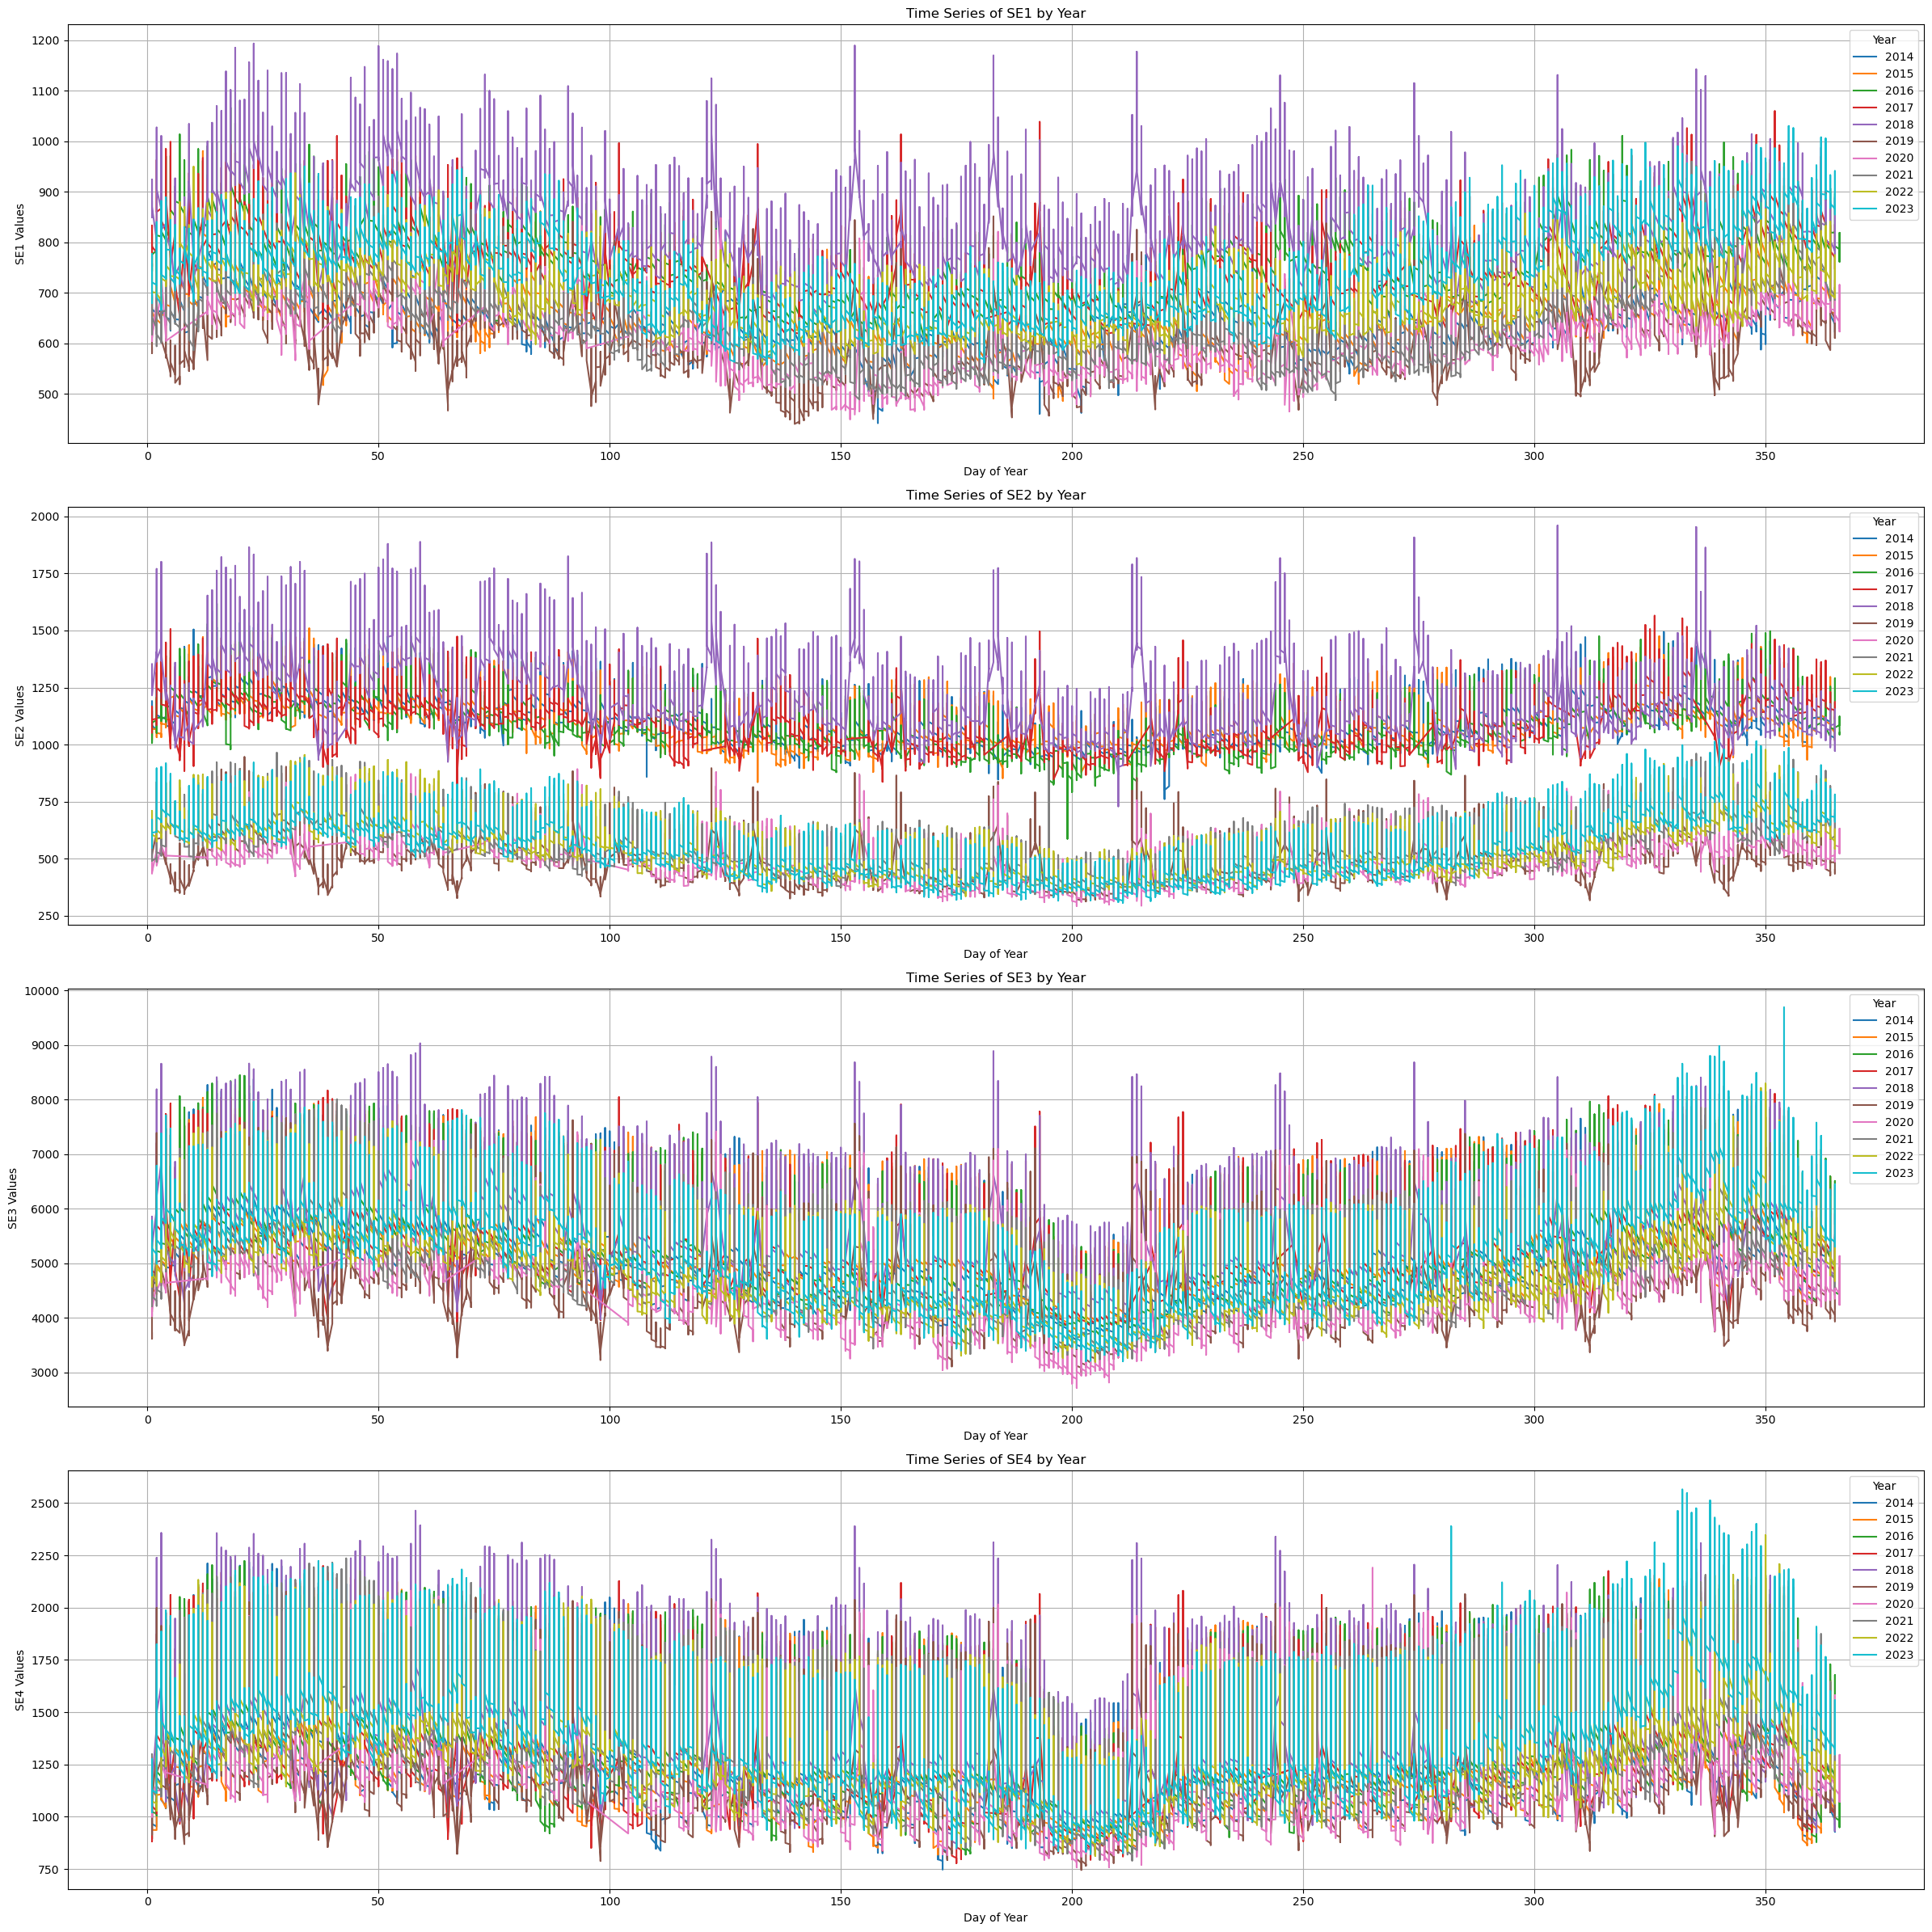

In [4]:
# Create a figure and an array of subplots (2 rows, 2 columns)
fig, axs = plt.subplots(4, 1, figsize=(24, 24))
se_columns = ['SE1', 'SE2', 'SE3', 'SE4']

# Iterate over each SE column and corresponding subplot
for i, se in enumerate(se_columns):
    ax = axs[i]  # Determine subplot position
    for year, data in load_curves[se].groupby(load_curves.index.year):
        # Use day of the year as x-axis for overlaying years
        data.index = data.index.dayofyear
        ax.plot(data.index, data.values, label=str(year))

    # Add title, labels, and legend to each subplot
    ax.set_title(f"Time Series of {se} by Year")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel(f"{se} Values")
    ax.legend(title="Year")
    ax.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [5]:
norm_load_curves = load_curves.copy()

for col in norm_load_curves.columns:
    norm_load_curves[col] = load_curves[col].div(load_curves.groupby(load_curves.index.year)[col].transform('sum'))


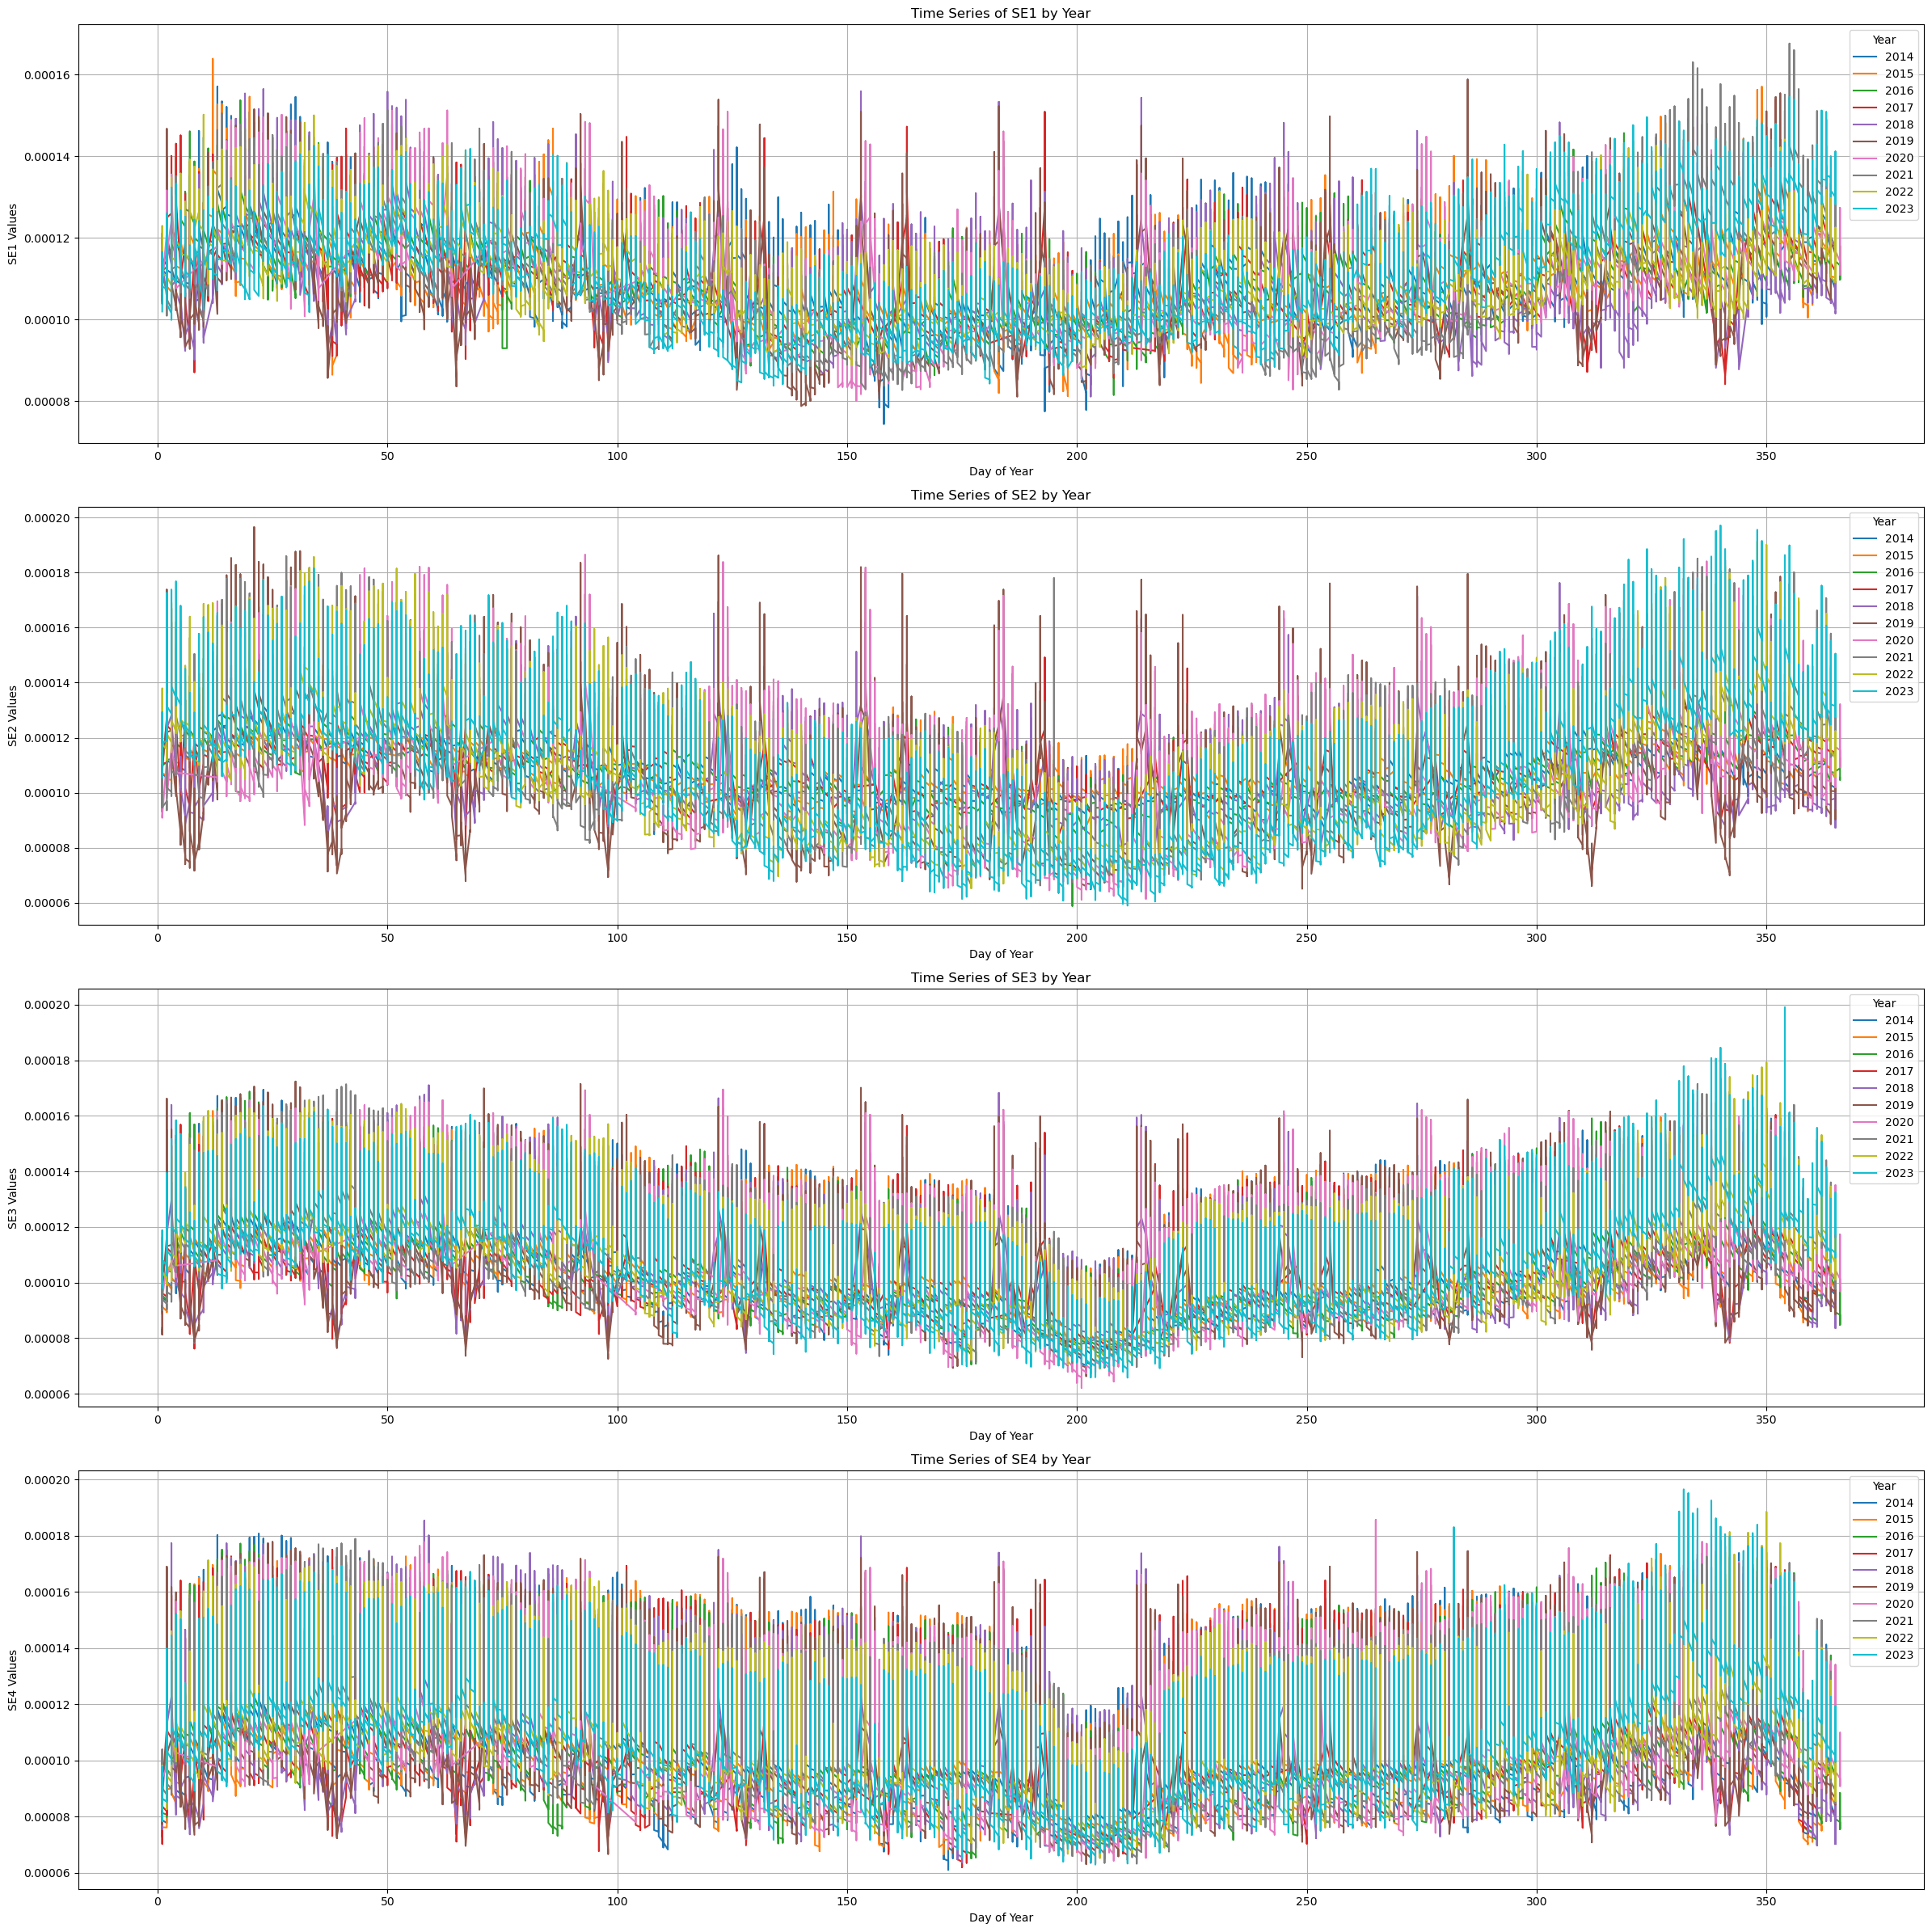

In [6]:
# Create a figure and an array of subplots (2 rows, 2 columns)
fig, axs = plt.subplots(4, 1, figsize=(24, 24))
se_columns = ['SE1', 'SE2', 'SE3', 'SE4']

# Iterate over each SE column and corresponding subplot
for i, se in enumerate(se_columns):
    ax = axs[i]  # Determine subplot position
    for year, data in norm_load_curves[se].groupby(load_curves.index.year):
        # Use day of the year as x-axis for overlaying years
        data.index = data.index.dayofyear
        ax.plot(data.index, data.values, label=str(year))

    # Add title, labels, and legend to each subplot
    ax.set_title(f"Time Series of {se} by Year")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel(f"{se} Values")
    ax.legend(title="Year")
    ax.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [7]:
# Some analytics on the daily amplitude

daily_max = norm_load_curves.resample('D').max()
daily_min = norm_load_curves.resample('D').min()
daily_amplitude = daily_max - daily_min
daily_amplitude.groupby(daily_amplitude.index.year).mean()

,SE1,SE2,SE3,SE4
timestamp,,,,
2014,0.000021,0.000020,0.000035,0.000049
2015,0.000020,0.000021,0.000034,0.000048
2016,0.000017,0.000021,0.000034,0.000047
2017,0.000019,0.000022,0.000035,0.000049
2018,0.000021,0.000026,0.000033,0.000047
2019,0.000021,0.000040,0.000038,0.000048
2020,0.000021,0.000041,0.000037,0.000048
2021,0.000019,0.000036,0.000033,0.000042
2022,0.000018,0.000036,0.000032,0.000040


In [8]:
# Some analytics on correlation

norm_load_curves_aligned = norm_load_curves[~((norm_load_curves.index.month == 2) & (norm_load_curves.index.day == 29))]
norm_load_curves_aligned['day_hour'] = norm_load_curves_aligned.index.strftime('%j-%H')  # Format as 'day-hour' (e.g., '001-00' for Jan 1, 00:00)
yearly_data = {year: data.set_index('day_hour') for year, data in norm_load_curves_aligned.groupby(norm_load_curves.index.year)}
years = list(yearly_data.keys())

correlation_matrices = {}

for col in norm_load_curves.columns:
    correlation_matrix = pd.DataFrame(index=years, columns=years)

    # Calculate correlations between each pair of years
    for year1 in years:
        for year2 in years:
            if year1 != year2:
                # Concatenate data for the specified column, aligning by 'day_hour'
                aligned_data = pd.concat([yearly_data[year1][col], yearly_data[year2][col]], axis=1, keys=[year1, year2])
                correlation = aligned_data.corr().iloc[0, 1]  # Extract correlation between the two columns
                correlation_matrix.loc[year1, year2] = correlation
            else:
                correlation_matrix.loc[year1, year2] = 1  # Correlation of a year with itself is 1

    correlation_matrices[col] = correlation_matrix

/tmp/ipykernel_1654616/3632071981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  norm_load_curves_aligned['day_hour'] = norm_load_curves_aligned.index.strftime('%j-%H')  # Format as 'day-hour' (e.g., '001-00' for Jan 1, 00:00)


ValueError: Grouper and axis must be same length

In [ ]:
correlation_matrices['SE1']

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
2014,1.0,0.70466,0.561902,0.469073,0.438678,0.605529,0.807875,0.557049,0.533869,0.507613
2015,0.70466,1.0,0.721202,0.455457,0.405499,0.48551,0.667738,0.711308,0.556323,0.526324
2016,0.561902,0.721202,1.0,0.507794,0.401678,0.441991,0.566156,0.866607,0.74645,0.58969
2017,0.469073,0.455457,0.507794,1.0,0.616744,0.561545,0.534175,0.510616,0.625329,0.682
2018,0.438678,0.405499,0.401678,0.616744,1.0,0.686252,0.483577,0.382448,0.430862,0.441249
2019,0.605529,0.48551,0.441991,0.561545,0.686252,1.0,0.634074,0.428796,0.44815,0.464557
2020,0.807875,0.667738,0.566156,0.534175,0.483577,0.634074,1.0,0.563246,0.550314,0.555705
2021,0.557049,0.711308,0.866607,0.510616,0.382448,0.428796,0.563246,1.0,0.778731,0.663971
2022,0.533869,0.556323,0.74645,0.625329,0.430862,0.44815,0.550314,0.778731,1.0,0.780132
2023,0.507613,0.526324,0.58969,0.682,0.441249,0.464557,0.555705,0.663971,0.780132,1.0


In [ ]:
correlation_matrices['SE2']

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
2014,1.0,0.70466,0.561902,0.469073,0.438678,0.605529,0.807875,0.557049,0.533869,0.507613
2015,0.70466,1.0,0.721202,0.455457,0.405499,0.48551,0.667738,0.711308,0.556323,0.526324
2016,0.561902,0.721202,1.0,0.507794,0.401678,0.441991,0.566156,0.866607,0.74645,0.58969
2017,0.469073,0.455457,0.507794,1.0,0.616744,0.561545,0.534175,0.510616,0.625329,0.682
2018,0.438678,0.405499,0.401678,0.616744,1.0,0.686252,0.483577,0.382448,0.430862,0.441249
2019,0.605529,0.48551,0.441991,0.561545,0.686252,1.0,0.634074,0.428796,0.44815,0.464557
2020,0.807875,0.667738,0.566156,0.534175,0.483577,0.634074,1.0,0.563246,0.550314,0.555705
2021,0.557049,0.711308,0.866607,0.510616,0.382448,0.428796,0.563246,1.0,0.778731,0.663971
2022,0.533869,0.556323,0.74645,0.625329,0.430862,0.44815,0.550314,0.778731,1.0,0.780132
2023,0.507613,0.526324,0.58969,0.682,0.441249,0.464557,0.555705,0.663971,0.780132,1.0


In [ ]:
correlation_matrices['SE3']

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
2014,1.0,0.70466,0.561902,0.469073,0.438678,0.605529,0.807875,0.557049,0.533869,0.507613
2015,0.70466,1.0,0.721202,0.455457,0.405499,0.48551,0.667738,0.711308,0.556323,0.526324
2016,0.561902,0.721202,1.0,0.507794,0.401678,0.441991,0.566156,0.866607,0.74645,0.58969
2017,0.469073,0.455457,0.507794,1.0,0.616744,0.561545,0.534175,0.510616,0.625329,0.682
2018,0.438678,0.405499,0.401678,0.616744,1.0,0.686252,0.483577,0.382448,0.430862,0.441249
2019,0.605529,0.48551,0.441991,0.561545,0.686252,1.0,0.634074,0.428796,0.44815,0.464557
2020,0.807875,0.667738,0.566156,0.534175,0.483577,0.634074,1.0,0.563246,0.550314,0.555705
2021,0.557049,0.711308,0.866607,0.510616,0.382448,0.428796,0.563246,1.0,0.778731,0.663971
2022,0.533869,0.556323,0.74645,0.625329,0.430862,0.44815,0.550314,0.778731,1.0,0.780132
2023,0.507613,0.526324,0.58969,0.682,0.441249,0.464557,0.555705,0.663971,0.780132,1.0


In [ ]:
correlation_matrices['SE4']

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
2014,1.0,0.70466,0.561902,0.469073,0.438678,0.605529,0.807875,0.557049,0.533869,0.507613
2015,0.70466,1.0,0.721202,0.455457,0.405499,0.48551,0.667738,0.711308,0.556323,0.526324
2016,0.561902,0.721202,1.0,0.507794,0.401678,0.441991,0.566156,0.866607,0.74645,0.58969
2017,0.469073,0.455457,0.507794,1.0,0.616744,0.561545,0.534175,0.510616,0.625329,0.682
2018,0.438678,0.405499,0.401678,0.616744,1.0,0.686252,0.483577,0.382448,0.430862,0.441249
2019,0.605529,0.48551,0.441991,0.561545,0.686252,1.0,0.634074,0.428796,0.44815,0.464557
2020,0.807875,0.667738,0.566156,0.534175,0.483577,0.634074,1.0,0.563246,0.550314,0.555705
2021,0.557049,0.711308,0.866607,0.510616,0.382448,0.428796,0.563246,1.0,0.778731,0.663971
2022,0.533869,0.556323,0.74645,0.625329,0.430862,0.44815,0.550314,0.778731,1.0,0.780132
2023,0.507613,0.526324,0.58969,0.682,0.441249,0.464557,0.555705,0.663971,0.780132,1.0
